Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


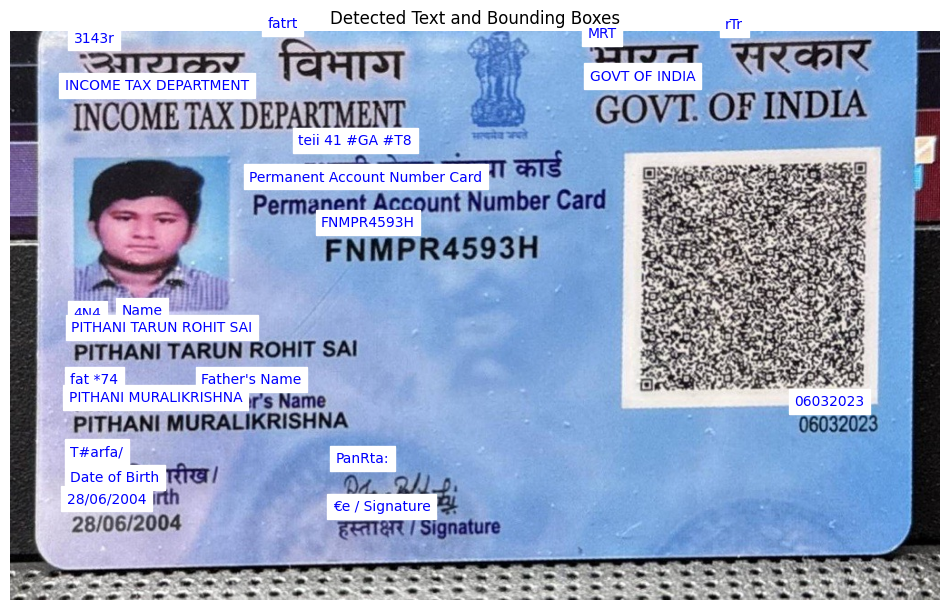


📄 Card Type: PAN
🧾 Format Used: pan_format1.json

🔍 Extracted Details:
PAN_No: FNMPR4593H
Person_Name: PITHANI TARUN ROHIT SAI
Father_Name: PITHANI MURALIKRISHNA
DOB: 28/06/2004


In [17]:
import re
import json
import easyocr
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image
import os

# Load JSON configuration file
def load_json_config(json_filename):
    path = os.path.join("templates", json_filename)
    with open(path, 'r') as f:
        return json.load(f)

# Detect if the card is PAN or Aadhaar
def detect_card_type(text_lines):
    joined_text = ' '.join([line.lower() for line in text_lines])
    if any(x in joined_text for x in ['income tax department', 'permanent account number', 'govt. of india', 'signature', 'permanent account number card']):
        return 'pan'
    elif any(x in joined_text for x in ['aadhaar', 'uidai', 'government of india','Unique Identification Authority of India']):
        return 'aadhaar'
    return 'unknown'

# Determine PAN format based on position of PAN number and DOB
def detect_pan_format(text_lines):
    pan_idx = -1
    dob_idx = -1

    pan_found = False
    dob_found = False
    
    # Check for PAN number and DOB positions
    for i, line in enumerate(text_lines):
        if re.search(r'\b[A-Z]{5}[0-9]{4}[A-Z]\b', line):  # PAN pattern
            pan_idx = i
            pan_found = True
        if re.search(r'\d{2}/\d{2}/\d{4}', line):  # DOB pattern
            dob_idx = i
            dob_found = True
    
    # If both PAN and DOB are found, determine format
    if pan_found and dob_found:
        if pan_idx < dob_idx:
            return 'pan_format1.json'  # PAN above DOB -> Format 1
        elif pan_idx > dob_idx:
            return 'pan_format2.json'  # PAN below DOB -> Format 2
    
    return 'pan_format1.json'  # Default to format 1 if not detected properly

# Extract PAN number using fallback search method if not found
def extract_pan_number(text_lines):
    # Check if PAN number is already detected
    for line in text_lines:
        match = re.search(r'\b[A-Z]{5}[0-9]{4}[A-Z]\b', line)
        if match:
            return match.group().strip()

    # If not found, look for "Permanent Account Number" or "Permanent Account Number Card" and extract PAN from the next line
    for i, line in enumerate(text_lines):
        if "permanent account number" in line.lower() or "permanent account number card" in line.lower():
            if i + 1 < len(text_lines):
                pan_match = re.search(r'\b[A-Z]{5}[0-9]{4}[A-Z]\b', text_lines[i + 1])
                if pan_match:
                    return pan_match.group().strip()
    return None

# Extract information using the config
def extract_by_config(text_lines, config):
    extracted = {}
    line_used = set()

    for key, rule in config.items():
        heading = rule.get('heading', "")
        direction = rule.get('direction')
        format_type = rule.get('format')
        pattern = rule.get('pattern', "")
        line_offset = rule.get('line_offset', 1)

        heading_lines = []
        if isinstance(heading, list):
            heading_lines = [i for i, line in enumerate(text_lines) if any(h.lower() in line.lower() for h in heading)]
        elif heading:
            heading_lines = [i for i, line in enumerate(text_lines) if heading.lower() in line.lower()]
        else:
            heading_lines = list(range(len(text_lines)))

        if format_type in ["pattern", "date", "regex"]:
            regex = pattern.replace("C", "[A-Z]").replace("N", "[0-9]") if format_type != "regex" else pattern
            for line in text_lines:
                match = re.search(regex, line)
                if match:
                    extracted[key] = match.group().strip()
                    break

        elif format_type == "line_relative":
            matched_lines = []
            if direction == "down":
                for idx in heading_lines:
                    if idx + line_offset < len(text_lines):
                        matched_lines.append((idx + line_offset, text_lines[idx + line_offset]))
            elif direction == "up":
                for idx in heading_lines:
                    if idx - line_offset >= 0:
                        matched_lines.append((idx - line_offset, text_lines[idx - line_offset]))

            if matched_lines:
                if key == "Person_Name":
                    idx, value = matched_lines[0]
                    extracted[key] = value.strip()
                    line_used.add(idx)

                elif key == "Father_Name":
                    # Try to find a different line after person name
                    for idx, value in matched_lines:
                        if idx not in line_used:
                            extracted[key] = value.strip()
                            line_used.add(idx)
                            break
                    else:
                        # fallback: try the next line after person name
                        if "Person_Name" in extracted:
                            person_line_idx = next((i for i, l in enumerate(text_lines) if extracted["Person_Name"] in l), -1)
                            if person_line_idx != -1 and person_line_idx + 1 < len(text_lines):
                                fallback_line = text_lines[person_line_idx + 1].strip()
                                if fallback_line and fallback_line not in extracted.values():
                                    extracted[key] = fallback_line

                else:
                    extracted[key] = matched_lines[0][1].strip()

    return extracted

# Draw bounding boxes with text
def display_with_boxes(image_path, results):

    image = Image.open(image_path)
    fig, ax = plt.subplots(figsize=(12, 12))
    ax.imshow(image)

    for (bbox, text, _) in results:
        (top_left, top_right, bottom_right, bottom_left) = bbox
        x, y = top_left
        width = top_right[0] - top_left[0]
        height = bottom_left[1] - top_left[1]
        rect = Rectangle((x, y), width, height, linewidth=1.5, edgecolor='red', facecolor='none')
        
        ax.text(x, y - 5, text, fontsize=10, color='blue', backgroundcolor='white')

    plt.axis('off')
    plt.title("Detected Text and Bounding Boxes")
    plt.show()

# OCR pipeline
def run_ocr_pipeline(image_path):
    reader = easyocr.Reader(['en'])
    results = reader.readtext(image_path)

    if not results:
        print("No text detected.")
        return

    # Display bounding boxes
    display_with_boxes(image_path, results)

    # Get plain text lines
    text_lines = [text for _, text, _ in results]

    # Detect card type
    card_type = detect_card_type(text_lines)

    if card_type == 'pan':
        json_file = detect_pan_format(text_lines)
    elif card_type == 'aadhaar':
        print("Aadhaar logic not implemented in this version.")
        return
    else:
        print(json.dumps({"error": "Unable to determine card type"}, indent=2))
        return

    config = load_json_config(json_file)
    extracted = extract_by_config(text_lines, config)

    # Attempt to extract PAN number (fallback logic)
    pan_number = extract_pan_number(text_lines)
    if pan_number:
        extracted["PAN_No"] = pan_number

    print(f"\n📄 Card Type: {card_type.upper()}")
    print(f"🧾 Format Used: {json_file}\n")

    if not extracted:
        print("No details extracted.")
    else:
        print("🔍 Extracted Details:")
        for key, value in extracted.items():
            print(f"{key}: {value}")

# Run with your image
if __name__ == "__main__":
    image_path = "pancard/15.jpg"  # Change as needed
    run_ocr_pipeline(image_path)


Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


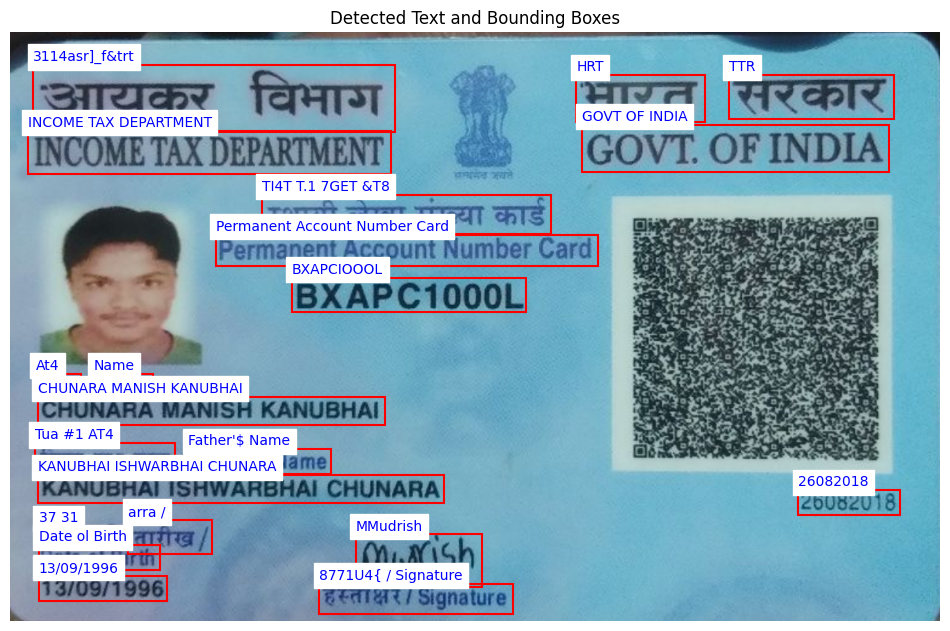

['3114asr]_f&trt', 'HRT', 'TTR', 'INCOME TAX DEPARTMENT', 'GOVT OF INDIA', 'TI4T T.1 7GET &T8', 'Permanent Account Number Card', 'BXAPCIOOOL', 'At4', 'Name', 'CHUNARA MANISH KANUBHAI', 'Tua #1 AT4', "Father'$ Name", 'KANUBHAI ISHWARBHAI CHUNARA', '26082018', '37 31', 'arra /', 'Date ol Birth', '13/09/1996', '8771U4{ / Signature', 'MMudrish']

📄 Card Type: PAN
🧾 Format Used: pan_format1.json

🔍 Extracted Details:
Person_Name: CHUNARA MANISH KANUBHAI
Father_Name: KANUBHAI ISHWARBHAI CHUNARA
DOB: 13/09/1996


In [46]:
import re
import json
import easyocr
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image
import os

def clean_text(text):
    return ''.join(c for c in text if c.isprintable() and not (0xD800 <= ord(c) <= 0xDFFF))

def load_json_config(json_filename):
    path = os.path.join("templates", json_filename)
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)

def detect_card_type(text_lines):
    joined_text = ' '.join([line.lower() for line in text_lines])
    if any(x in joined_text for x in ['income tax department', 'permanent account number', 'govt. of india', 'signature', 'permanent account number card','govt of india']):
        return 'pan'
    elif any(x in joined_text for x in ['aadhaar', 'uidai', 'government of india','unique identification authority of india','government oi india','Address']):
        return 'aadhaar'
    return 'unknown'

def detect_pan_format(text_lines):
    pan_idx = -1
    dob_idx = -1
    for i, line in enumerate(text_lines):
        if re.search(r'\b[A-Z]{5}[0-9]{4}[A-Z]\b', line):
            pan_idx = i
        if re.search(r'\d{2}/\d{2}/\d{4}', line):
            dob_idx = i
    return 'pan_format1.json' if pan_idx < dob_idx else 'pan_format2.json'

def detect_aadhaar_format(text_lines):
    joined_text = ' '.join([line.lower() for line in text_lines])
    if any(x in joined_text for x in ["address", "s/o", "d/o", "w/o", "c/o", "पताः", "पता"]):
        return 'aadhaar_back.json'
    return 'aadhaar_front.json'

def extract_pan_number(text_lines):
    for line in text_lines:
        match = re.search(r'\b[A-Z]{5}[0-9]{4}[A-Z]\b', line)
        if match:
            return match.group().strip()
    return None

def extract_pan_by_config(text_lines, config):
    extracted = {}
    for key, rule in config.items():
        heading = rule.get('heading', "")
        direction = rule.get('direction')
        format_type = rule.get('format')
        pattern = rule.get('pattern', "")
        line_offset = rule.get('line_offset', 1)

        heading_lines = []
        if isinstance(heading, list):
            heading_lines = [i for i, line in enumerate(text_lines) if any(h.lower() in line.lower() for h in heading)]
        elif heading:
            heading_lines = [i for i, line in enumerate(text_lines) if heading.lower() in line.lower()]
        else:
            heading_lines = list(range(len(text_lines)))

        if format_type in ["pattern", "date"]:
            regex = pattern.replace("C", "[A-Z]").replace("N", "[0-9]")
            for line in text_lines:
                match = re.search(regex, line)
                if match:
                    extracted[key] = clean_text(match.group().strip())
                    break
        elif format_type == "line_relative":
            for idx in heading_lines:
                new_idx = idx + line_offset if direction == "down" else idx - line_offset
                if 0 <= new_idx < len(text_lines):
                    extracted[key] = clean_text(text_lines[new_idx].strip())
                    break
    return extracted

def extract_aadhaar_by_config(text_lines, config):
    extracted = {}
    for key, rule in config.items():
        heading = rule.get('heading', "")
        direction = rule.get('direction')
        format_type = rule.get('format')
        pattern = rule.get('pattern', "")
        line_offset = rule.get('line_offset', 1)
        keywords = rule.get('keywords', [])

        heading_lines = []
        if isinstance(heading, list):
            heading_lines = [i for i, line in enumerate(text_lines) if any(h.lower() in line.lower() for h in heading)]
        elif heading:
            heading_lines = [i for i, line in enumerate(text_lines) if re.search(heading, line, re.IGNORECASE)]
        else:
            heading_lines = list(range(len(text_lines)))

        if format_type == "regex":
            for line in text_lines:
                match = re.search(pattern, line)
                if match:
                    extracted[key] = clean_text(match.group(1).strip() if match.groups() else match.group().strip())
                    break
        elif format_type == "keyword":
            for line in text_lines:
                for keyword in keywords:
                    if keyword.lower() in line.lower():
                        extracted[key] = keyword
                        break
        elif format_type == "line_relative":
            if key == "Person_Name":
                for idx in heading_lines:
                    for offset in line_offset:
                        new_idx = idx - offset
                        while new_idx >= 0:
                            text = text_lines[new_idx].strip()
                            if not re.search(r'[A-Za-z]', text) or re.search(r'[^A-Za-z\s]', text):
                                new_idx -= 1
                                continue
                            if 2 <= len(text.split()) <= 5:
                                extracted[key] = clean_text(text)
                                break
                            new_idx -= 1
                        if key in extracted:
                            break
            else:
                offsets = line_offset if isinstance(line_offset, list) else [line_offset]
                for idx in heading_lines:
                    for offset in offsets:
                        new_idx = idx + offset if direction == "down" else idx - offset
                        if 0 <= new_idx < len(text_lines):
                            extracted[key] = clean_text(text_lines[new_idx].strip())
                            break
        elif format_type == "block" and direction == "below":
            for idx in heading_lines:
                block_lines = []
                seen_lines = set()
                for j in range(idx + 1, len(text_lines)):
                    line = clean_text(text_lines[j].strip())

                    if re.search(r'\d{4}\s?\d{4}\s?\d{4}', line) or len(re.findall(r'\d{6}', line)) >= 2:
                        break
                    if len(re.findall(r'\d', line)) > 10:
                        continue
                    if re.search(r'[\u0900-\u097F]', line) or len(line) <= 2:
                        continue
                    if any(x in line.lower() for x in ["uidai", "help", "toll", "visit", ".in", "gov", "www"]):
                        continue

                    cleaned = re.sub(r'[^\w\s,/-]', '', line)
                    if cleaned.lower() in seen_lines:
                        continue
                    seen_lines.add(cleaned.lower())
                    block_lines.append(cleaned)

                if block_lines:
                    extracted[key] = clean_text(' '.join(block_lines).strip())
                    break
    return extracted

def pan_details_extraction(text_lines, config):
    extracted = extract_pan_by_config(text_lines, config)
    pan_number = extract_pan_number(text_lines)
    if pan_number:
        extracted["PAN_No"] = clean_text(pan_number)
    return extracted

def aadhaar_details_extraction(text_lines, config, is_front):
    extracted = extract_aadhaar_by_config(text_lines, config)
    if is_front:
        gender_text = ' '.join(text_lines).lower()
        if "female" in gender_text:
            extracted["Gender"] = "Female"
        elif "male" in gender_text:
            extracted["Gender"] = "Male"
        elif re.search(r"\b(f|m)\b", gender_text):
            extracted["Gender"] = "Female" if "f" in gender_text else "Male"
    return extracted

def display_with_boxes(image_path, results):
    image = Image.open(image_path)
    fig, ax = plt.subplots(figsize=(12, 12))
    ax.imshow(image)
    for (bbox, text, _) in results:
        (top_left, top_right, bottom_right, bottom_left) = bbox
        x, y = top_left
        width = top_right[0] - top_left[0]
        height = bottom_left[1] - top_left[1]
        if height > width * 2:
            continue
        if re.search(r'[\u0900-\u097F]', text):
            continue
        rect = Rectangle((x, y), width, height, linewidth=1.5, edgecolor='red', facecolor='none')
        ax.add_patch(rect)
        ax.text(x, y - 5, clean_text(text), fontsize=10, color='blue', backgroundcolor='white')
    plt.axis('off')
    plt.title("Detected Text and Bounding Boxes")
    plt.show()

def run_ocr_pipeline(image_path):
    reader = easyocr.Reader(['en'])
    results = reader.readtext(image_path)
    if not results:
        print("No text detected.")
        return
    display_with_boxes(image_path, results)
    text_lines = []
    for (_, text, _) in results:
        text = clean_text(text)
        if not re.search(r'[\u0900-\u097F]', text):
            text_lines.append(text)
    print(text_lines)
    card_type = detect_card_type(text_lines)
    if card_type == 'pan':
        json_file = detect_pan_format(text_lines)
        config = load_json_config(json_file)
        extracted = pan_details_extraction(text_lines, config)
    elif card_type == 'aadhaar':
        json_file = detect_aadhaar_format(text_lines)
        config = load_json_config(json_file)
        is_front = json_file == 'aadhaar_front.json'
        extracted = aadhaar_details_extraction(text_lines, config, is_front)
    else:
        print(json.dumps({"error": "Unable to determine card type"}, indent=2))
        return
    print(f"\n📄 Card Type: {card_type.upper()}")
    print(f"🧾 Format Used: {json_file}\n")
    if not extracted:
        print("No details extracted.")
    else:
        print("🔍 Extracted Details:")
        for key, value in extracted.items():
            print(f"{key}: {value}")

if __name__ == "__main__":
    image_path = "pancard/3.png"  # Replace with your image path
    run_ocr_pipeline(image_path)


Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


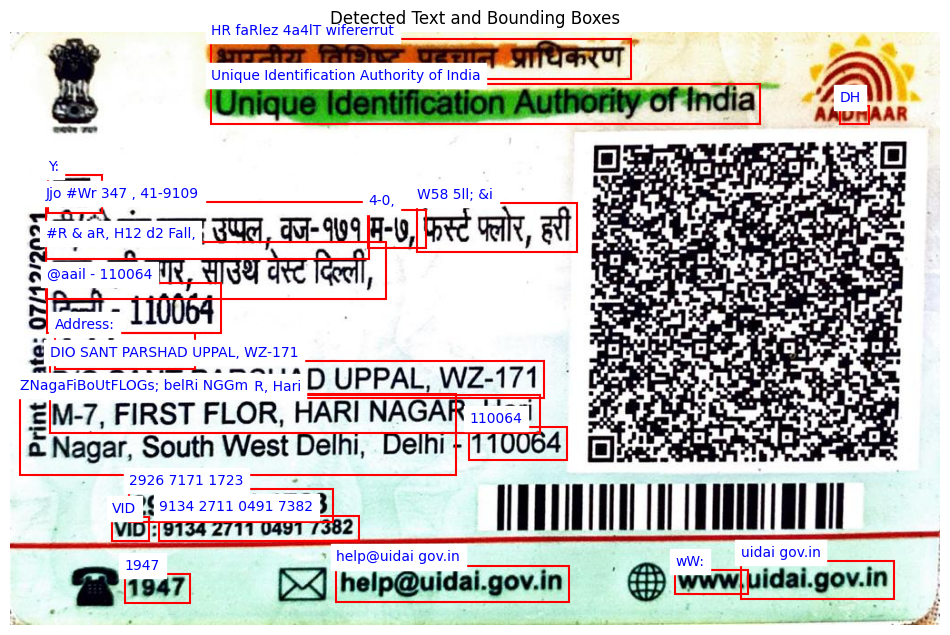

['HR faRlez 4a4lT wifererrut', 'Unique Identification Authority of India', 'DH', 'Y:', 'Jjo #Wr 347 , 41-9109', 'W58 5ll; &i', '1', '#R & aR, H12 d2 Fall,', '@aail - 110064', 'Address:', '3', 'DIO SANT PARSHAD UPPAL, WZ-171', 'M-7 , FIRST FLOR, HARI NAGAR, Hari', 'ZNagaFiBoUtFLOGs; belRi NGGm', '110064', '2926 7171 1723', 'VID', '9134 2711 0491 7382', '1947', 'help@uidai gov.in', 'wW:', 'uidai gov.in', '4-0,']

📄 Card Type: AADHAAR
📟 Format Used: aadhaar_back.json

🔍 Extracted Details:
Address: DIO SANT PARSHAD UPPAL, WZ-171 M-7 , FIRST FLOR, HARI NAGAR, Hari ZNagaFiBoUtFLOGs belRi NGGm
Pincode: 110064


In [37]:
import re
import json
import easyocr
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image
import os

def clean_text(text):
    return ''.join(c for c in text if c.isprintable() and not (0xD800 <= ord(c) <= 0xDFFF))

def load_json_config(json_filename):
    path = os.path.join("templates", json_filename)
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)

def detect_card_type(text_lines):
    joined_text = ' '.join([line.lower() for line in text_lines])
    if any(x in joined_text for x in ['income tax department', 'permanent account number', 'govt. of india', 'signature', 'permanent account number card','govt of india']):
        return 'pan'
    elif any(x in joined_text for x in ['aadhaar', 'uidai', 'government of india','unique identification authority of india','government oi india','Address']):
        return 'aadhaar'
    return 'unknown'

def detect_pan_format(text_lines):
    pan_idx = -1
    dob_idx = -1
    for i, line in enumerate(text_lines):
        if re.search(r'\b[A-Z]{5}[0-9]{4}[A-Z]\b', line):
            pan_idx = i
        if re.search(r'\d{2}/\d{2}/\d{4}', line):
            dob_idx = i
    return 'pan_format1.json' if pan_idx < dob_idx else 'pan_format2.json'

def detect_aadhaar_format(text_lines):
    joined_text = ' '.join([line.lower() for line in text_lines])
    if any(x in joined_text for x in ["address", "s/o", "d/o", "w/o", "c/o", "पताः", "पता"]):
        return 'aadhaar_back.json'
    return 'aadhaar_front.json'

def extract_pan_number(text_lines):
    for line in text_lines:
        match = re.search(r'\b[A-Z]{5}[0-9]{4}[A-Z]\b', line)
        if match:
            return match.group().strip()
    return None

def extract_pan_by_config(text_lines, config):
    extracted = {}
    for key, rule in config.items():
        heading = rule.get('heading', "")
        direction = rule.get('direction')
        format_type = rule.get('format')
        pattern = rule.get('pattern', "")
        line_offset = rule.get('line_offset', 1)

        heading_lines = []
        if isinstance(heading, list):
            heading_lines = [i for i, line in enumerate(text_lines) if any(h.lower() in line.lower() for h in heading)]
        elif heading:
            heading_lines = [i for i, line in enumerate(text_lines) if heading.lower() in line.lower()]
        else:
            heading_lines = list(range(len(text_lines)))

        if format_type in ["pattern", "date"]:
            regex = pattern.replace("C", "[A-Z]").replace("N", "[0-9]")
            for line in text_lines:
                match = re.search(regex, line)
                if match:
                    extracted[key] = clean_text(match.group().strip())
                    break
        elif format_type == "line_relative":
            for idx in heading_lines:
                new_idx = idx + line_offset if direction == "down" else idx - line_offset
                if 0 <= new_idx < len(text_lines):
                    extracted[key] = clean_text(text_lines[new_idx].strip())
                    break
    return extracted

def extract_aadhaar_by_config(text_lines, config, is_front):
    if not is_front:
        extracted = {}
        address_lines = []
        collecting = False
        pincode = None
        seen_lines = set()
        for line in text_lines:
            cleaned = clean_text(line).strip()
            if re.search(r'[\u0900-\u097F]', cleaned) or len(cleaned) <= 2:
                continue
            if any(x in cleaned.lower() for x in ['uidai', 'help', 'visit', '.in', 'gov', 'www']):
                continue
            if 'address' in cleaned.lower():
                collecting = True
                continue
            if collecting:
                if re.search(r'\b\d{6}\b', cleaned):
                    match = re.search(r'\b\d{6}\b', cleaned)
                    pincode = match.group(0)
                    break
                if len(re.findall(r'\d', cleaned)) > 10:
                    continue
                line_no_junk = re.sub(r'[^\w\s,/-]', '', cleaned)
                if line_no_junk.lower() in seen_lines:
                    continue
                seen_lines.add(line_no_junk.lower())
                address_lines.append(line_no_junk)
        if address_lines:
            extracted["Address"] = ' '.join(address_lines)
        if pincode:
            extracted["Pincode"] = pincode
        return extracted

    # Aadhaar front fallback to JSON config logic
    extracted = {}
    for key, rule in config.items():
        heading = rule.get('heading', "")
        direction = rule.get('direction')
        format_type = rule.get('format')
        pattern = rule.get('pattern', "")
        line_offset = rule.get('line_offset', 1)
        keywords = rule.get('keywords', [])

        heading_lines = []
        if isinstance(heading, list):
            heading_lines = [i for i, line in enumerate(text_lines) if any(h.lower() in line.lower() for h in heading)]
        elif heading:
            heading_lines = [i for i, line in enumerate(text_lines) if re.search(heading, line, re.IGNORECASE)]
        else:
            heading_lines = list(range(len(text_lines)))

        if format_type == "regex":
            for line in text_lines:
                match = re.search(pattern, line)
                if match:
                    extracted[key] = clean_text(match.group(1).strip() if match.groups() else match.group().strip())
                    break
        elif format_type == "keyword":
            for line in text_lines:
                for keyword in keywords:
                    if keyword.lower() in line.lower():
                        extracted[key] = keyword
                        break
        elif format_type == "line_relative":
            offsets = line_offset if isinstance(line_offset, list) else [line_offset]
            for idx in heading_lines:
                for offset in offsets:
                    new_idx = idx + offset if direction == "down" else idx - offset
                    if 0 <= new_idx < len(text_lines):
                        extracted[key] = clean_text(text_lines[new_idx].strip())
                        break
    return extracted

def pan_details_extraction(text_lines, config):
    extracted = extract_pan_by_config(text_lines, config)
    pan_number = extract_pan_number(text_lines)
    if pan_number:
        extracted["PAN_No"] = clean_text(pan_number)
    return extracted

def aadhaar_details_extraction(text_lines, config, is_front):
    extracted = extract_aadhaar_by_config(text_lines, config, is_front)
    if is_front:
        gender_text = ' '.join(text_lines).lower()
        if "female" in gender_text:
            extracted["Gender"] = "Female"
        elif "male" in gender_text:
            extracted["Gender"] = "Male"
        elif re.search(r"\b(f|m)\b", gender_text):
            extracted["Gender"] = "Female" if "f" in gender_text else "Male"
    return extracted

def display_with_boxes(image_path, results):
    image = Image.open(image_path)
    fig, ax = plt.subplots(figsize=(12, 12))
    ax.imshow(image)
    for (bbox, text, _) in results:
        (top_left, top_right, bottom_right, bottom_left) = bbox
        x, y = top_left
        width = top_right[0] - top_left[0]
        height = bottom_left[1] - top_left[1]
        if height > width * 2:
            continue
        if re.search(r'[\u0900-\u097F]', text):
            continue
        rect = Rectangle((x, y), width, height, linewidth=1.5, edgecolor='red', facecolor='none')
        ax.add_patch(rect)
        ax.text(x, y - 5, clean_text(text), fontsize=10, color='blue', backgroundcolor='white')
    plt.axis('off')
    plt.title("Detected Text and Bounding Boxes")
    plt.show()

def run_ocr_pipeline(image_path):
    reader = easyocr.Reader(['en'])
    results = reader.readtext(image_path)
    if not results:
        print("No text detected.")
        return
    display_with_boxes(image_path, results)
    text_lines = []
    for (_, text, _) in results:
        text = clean_text(text)
        if not re.search(r'[\u0900-\u097F]', text):
            text_lines.append(text)
    print(text_lines)
    card_type = detect_card_type(text_lines)
    if card_type == 'pan':
        json_file = detect_pan_format(text_lines)
        config = load_json_config(json_file)
        extracted = pan_details_extraction(text_lines, config)
    elif card_type == 'aadhaar':
        json_file = detect_aadhaar_format(text_lines)
        config = load_json_config(json_file)
        is_front = json_file == 'aadhaar_front.json'
        extracted = aadhaar_details_extraction(text_lines, config, is_front)
    else:
        print(json.dumps({"error": "Unable to determine card type"}, indent=2))
        return
    print(f"\n📄 Card Type: {card_type.upper()}")
    print(f"📟 Format Used: {json_file}\n")
    if not extracted:
        print("No details extracted.")
    else:
        print("🔍 Extracted Details:")
        for key, value in extracted.items():
            print(f"{key}: {value}")

if __name__ == "__main__":
    image_path = "aadhaar/back/2.jpeg"  # Replace with your image path
    run_ocr_pipeline(image_path)
